                Category                         Metric  \
0        Company profile                  Primary focus   
1            Market data  Approx. market capitalisation   
2  Financial performance                   2025 revenue   
3  Financial performance                  2025 GAAP EPS   
4  Financial performance     2025 adjusted/non-GAAP EPS   

                                      AbbVie (ABBV)  \
0    Immunology, oncology, neuroscience, aesthetics   
1  $460B user-provided; ~$471B market-data snapshot   
2                                           $61.16B   
3                                             $2.36   
4                                            $10.00   

                                        Merck (MRK)  \
0                 Oncology, vaccines, animal health   
1  $371B user-provided; ~$346B market-data snapshot   
2                                            $65.0B   
3                                             $7.28   
4                                      

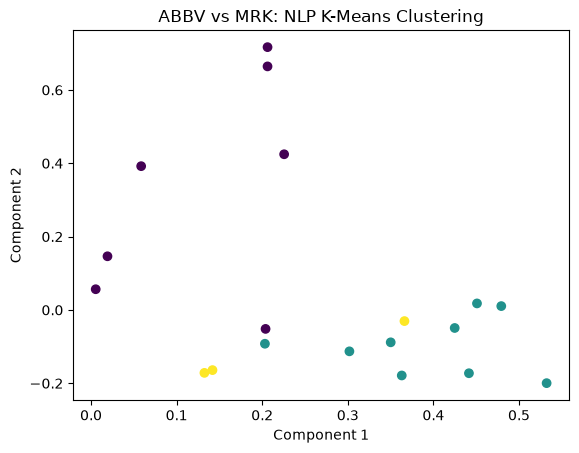

Analysis complete!


In [1]:
# Install if needed:
# !pip install pandas matplotlib scikit-learn

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import silhouette_score

# 1. Load dataset
df = pd.read_csv("ABBV_vs_MRK_comparison.csv")
print(df.head())
print(df.info())

# 2. Combine text columns
text_cols = df.select_dtypes(include=["object", "string"]).columns
df["text"] = df[text_cols].fillna("").astype(str).agg(" ".join, axis=1)

# 3. NLP: TF-IDF
tfidf = TfidfVectorizer(stop_words="english", max_features=2000)
X = tfidf.fit_transform(df["text"])

# 4. K-Means clustering
k = min(3, X.shape[0])
if k < 2:
    raise ValueError("At least 2 records are needed for clustering.")

model = KMeans(n_clusters=k, random_state=42, n_init=10)
df["Cluster"] = model.fit_predict(X)

# 5. Evaluate clustering
print("Silhouette Score:", silhouette_score(X, df["Cluster"]))
print(df["Cluster"].value_counts())

# 6. Top words per cluster
terms = tfidf.get_feature_names_out()
for i, center in enumerate(model.cluster_centers_):
    words = terms[center.argsort()[-10:][::-1]]
    print(f"Cluster {i}:", ", ".join(words))

# 7. Visualize clusters
if X.shape[1] >= 2:
    coords = TruncatedSVD(n_components=2, random_state=42).fit_transform(X)
    plt.scatter(coords[:, 0], coords[:, 1], c=df["Cluster"], cmap="viridis")
    plt.title("ABBV vs MRK: NLP K-Means Clustering")
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.show()

# 8. Save results
df.to_csv("ABBV_vs_MRK_kmeans_NLP_results.csv", index=False)
print("Analysis complete!")